## Introduction

This project explores a medical insurance dataset containing demographic and lifestyle information for 1,338 individuals. The dataset includes age, sex, BMI, number of children, smoking status, region, and individual insurance charges.

The main objective of this exploratory data analysis is to understand the distribution of these variables and investigate how factors such as smoking status, age, BMI, and sex are associated with insurance charges. The analysis includes data-quality checks, descriptive statistics, categorical comparisons, and visual exploration of relationships between the available features and `charges`, which will later serve as the target variable for a regression model.

The findings are interpreted as associations within this dataset and should not be considered evidence of causal relationships.

## Import the Libraries

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the Dataset

In [68]:
df = pd.read_csv('insurance.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


## Cleaning the Data

In [69]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [70]:
df.drop_duplicates(inplace= True)

In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## EDA(Exploratory Data Analysis)

### Categorical Analysis

In [72]:
cat_features = df.select_dtypes(include='str').columns

for i in cat_features:
    print(f'{i}: {df[i].nunique()}\n{df[i].unique()}\n')

sex: 2
<StringArray>
['female', 'male']
Length: 2, dtype: str

smoker: 2
<StringArray>
['yes', 'no']
Length: 2, dtype: str

region: 4
<StringArray>
['southwest', 'southeast', 'northwest', 'northeast']
Length: 4, dtype: str



<Figure size 640x480 with 0 Axes>

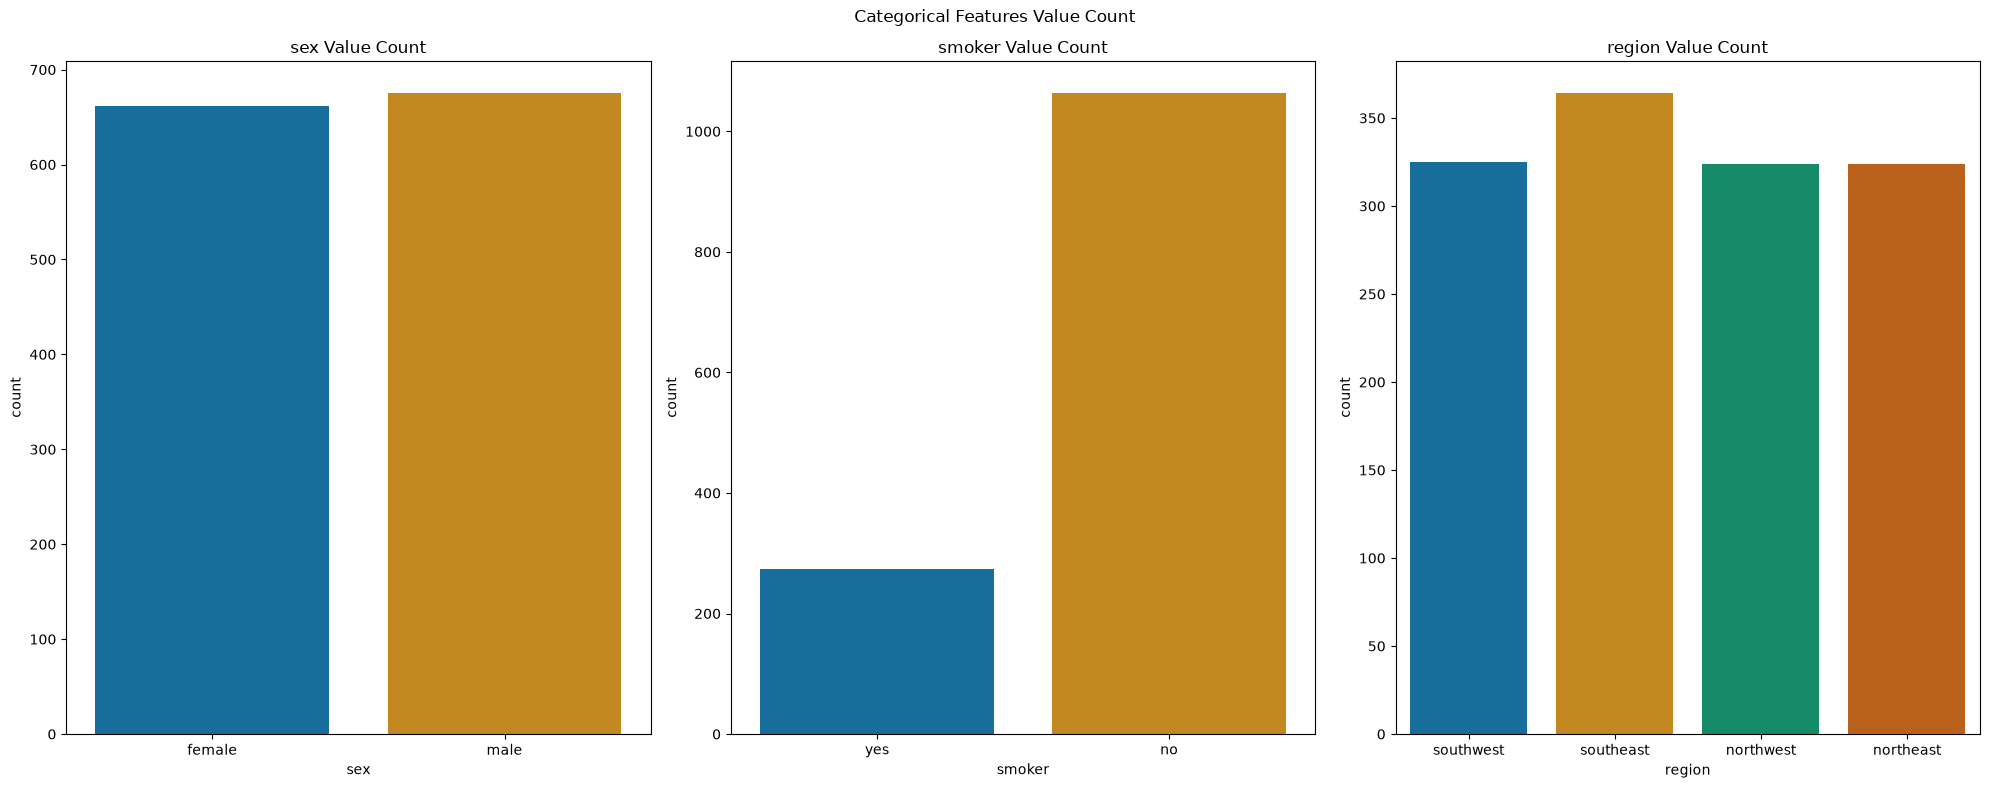

In [73]:
plt.figure()

fig, axes = plt.subplots(1,3, figsize=(20 ,8))
ax = axes.flatten()

for i, col in enumerate(cat_features):
    ax= axes[i]

    sns.countplot(data=df, x=col, hue=col, ax=ax, palette='colorblind')
    ax.set_title(f'{col} Value Count')

plt.suptitle('Categorical Features Value Count')
plt.tight_layout()
plt.show()

Distribution of male and female on dataset almost equal. 

Also it seems distribution of of every four region is almost equal, But Southeast is almost 3% higher than other regions.


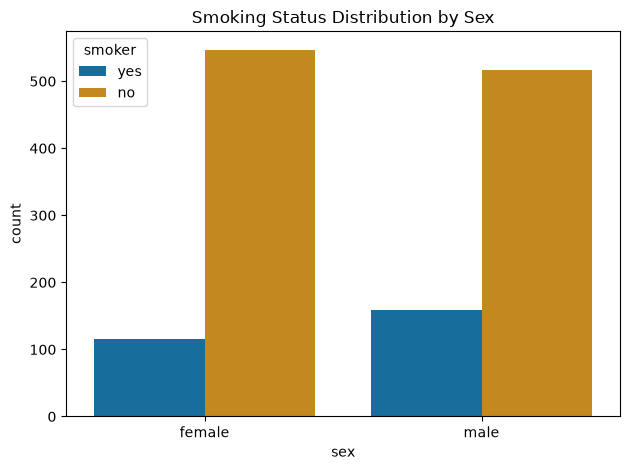

In [74]:
plt.figure()
sns.countplot(data =df, x='sex', hue='smoker', palette='colorblind')
plt.title('Smoking Status Distribution by Sex')
plt.tight_layout()
plt.show()

In [75]:
female_smokers = df[(df['sex'] == 'female') & (df['smoker'] == 'yes')]
female_smoker_percentage = len(female_smokers) / len(df[df['sex'] == 'female']) * 100

male_smokers = df[(df['sex'] == 'male') & (df['smoker'] == 'yes')]
male_smoker_percentage = len(male_smokers) / len(df[df['sex'] == 'male']) * 100

print(f'Female smoker percentage: {female_smoker_percentage:.2f}%')
print(f'Male smoker percentage: {male_smoker_percentage:.2f}%')

Female smoker percentage: 17.37%
Male smoker percentage: 23.56%


In [76]:
smoker_num = len(df[df['smoker'] == 'yes'])
non_smoker_num = len(df[df['smoker'] == 'no'])

print(f'Percentage of non-smoker people: {round((non_smoker_num / len(df)) * 100, 2)}%')
print(f'Percentage of smoker people: {round((smoker_num / len(df)) * 100, 2)}%\n')

total_charges = df['charges'].sum()
non_smoker_charges = df[df['smoker'] == 'no']['charges'].sum() 
smoker_charges = df[df['smoker'] == 'yes']['charges'].sum() 

print(f'Percentage of charges for non-smoker people : {round((non_smoker_charges / total_charges) * 100, 2)}%')
print(f'Percentage of charges for smoker people : {round((smoker_charges / total_charges ) * 100, 2)}%\n')

avg_non_smoker = round((non_smoker_charges / non_smoker_num), 2)
avg_smoker = round((smoker_charges / smoker_num), 2)

print(f'Average of every non-smoker person: {avg_non_smoker}')
print(f'Average of every smoker person: {avg_smoker}')


Percentage of non-smoker people: 79.51%
Percentage of smoker people: 20.49%

Percentage of charges for non-smoker people : 50.54%
Percentage of charges for smoker people : 49.46%

Average of every non-smoker person: 8440.66
Average of every smoker person: 32050.23


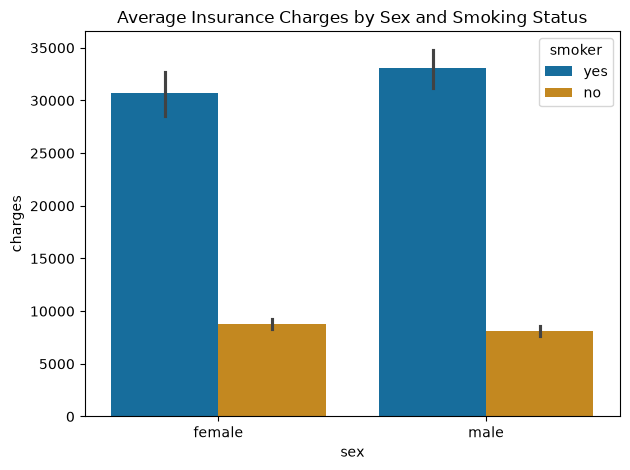

In [77]:
plt.figure()
sns.barplot(data=df, x='sex',hue='smoker', y='charges', palette='colorblind')
plt.title('Average Insurance Charges by Sex and Smoking Status')
plt.tight_layout()
plt.savefig('plot2')
plt.show()

Smoking is more common among males (23.56%) than females (17.37%), although smokers remain a minority in both groups. Overall, smokers represent only 20.49% of the dataset, while non-smokers account for 79.51%.

Despite their much smaller population, smokers account for 49.46% of total charges—almost equal to the 50.54% attributed to non-smokers. This means that approximately one-fifth of the observations generate nearly half of the total charges.

The average charge for a smoker is 32,050.23, compared with 8,440.66 for a non-smoker, making the average approximately 3.8 times higher among smokers. The same general pattern is visible for both females and males: smokers have substantially higher average charges than non-smokers, while the differences between the two sexes within each smoking group are comparatively smaller.

Overall, smoking status shows a strong association with higher insurance charges in this dataset and appears to be more informative than sex alone when comparing average charges.

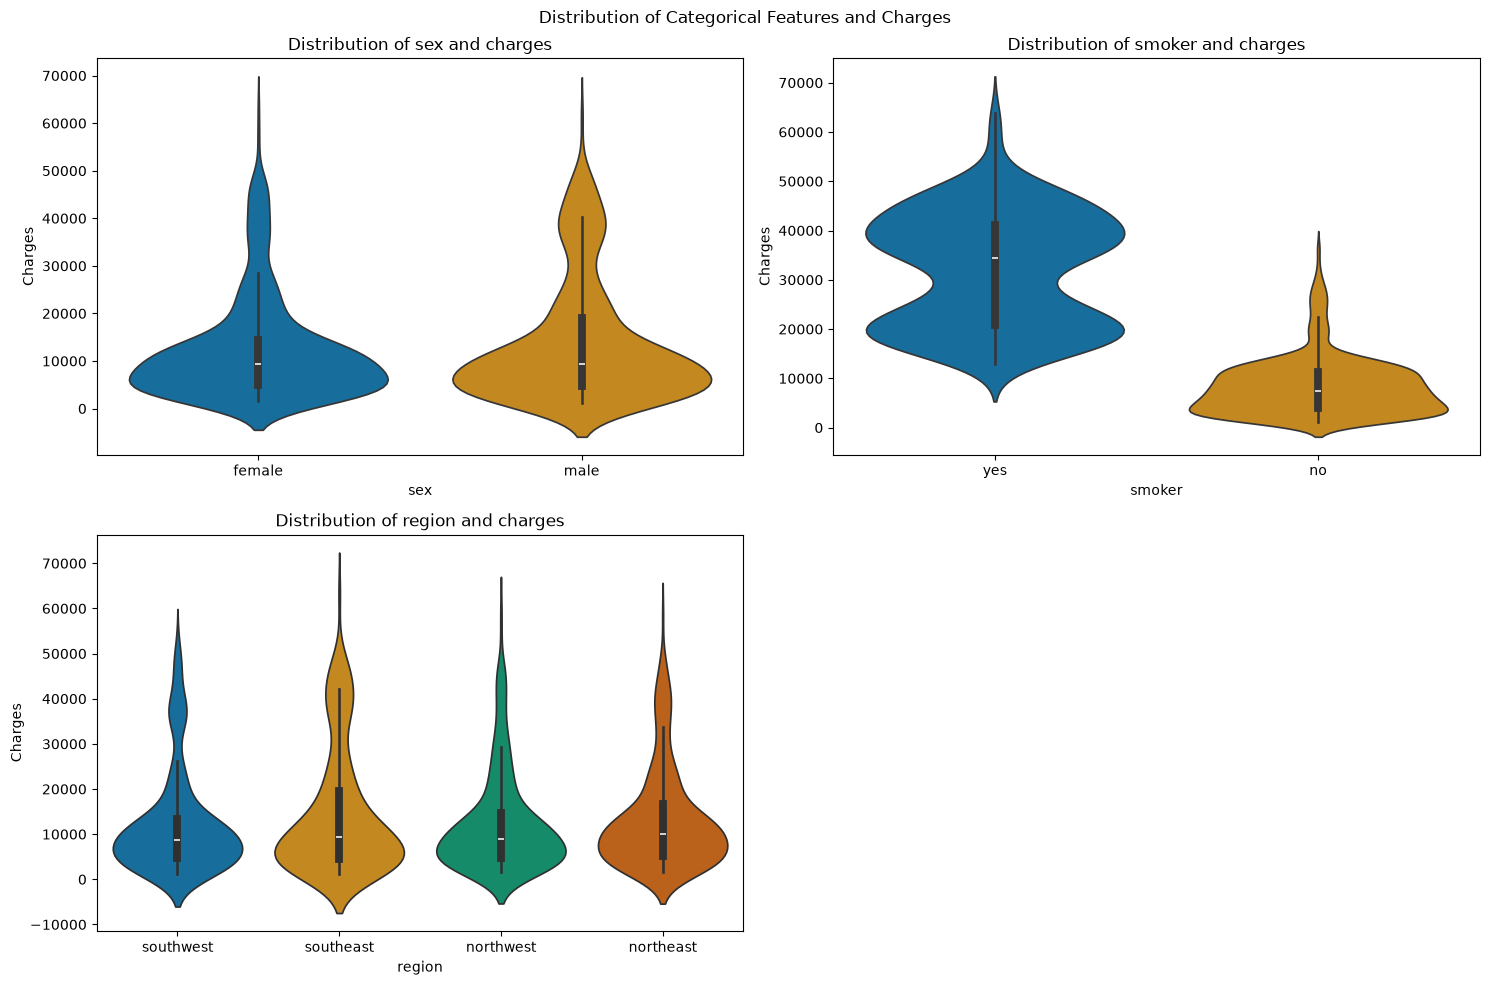

In [78]:
fig, axes = plt.subplots(2, 2, figsize= (15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    ax = axes[i]
    sns.violinplot(data=df, x=col, y='charges', hue=col, ax=ax, palette='colorblind')
    ax.set_xlabel(col)
    ax.set_ylabel('Charges')
    ax.set_title(f'Distribution of {col} and charges')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.suptitle('Distribution of Categorical Features and Charges')
plt.tight_layout()
plt.show()



### Numerical Analysis

In [79]:
num_feature = df.select_dtypes(include=['int64', 'float64']).columns
for i in num_feature:
    print(f'{i}:{df[i].nunique()}\n')

age:47

bmi:548

children:6

charges:1337



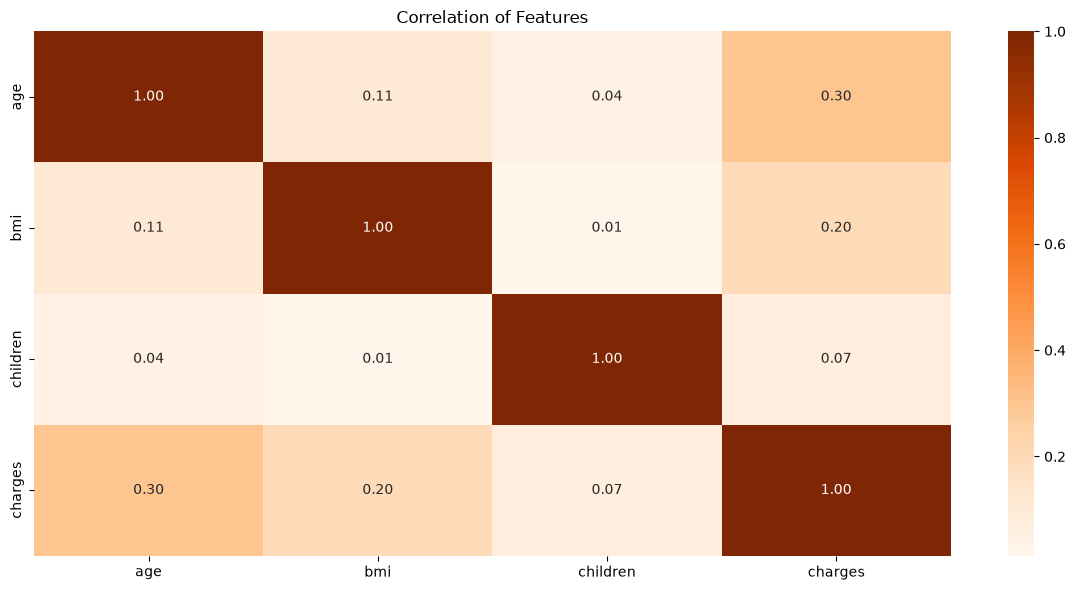

In [80]:
corr_matrix = df[num_feature].corr()

plt.figure(figsize= (12, 6))
sns.heatmap(data= corr_matrix, annot= True, fmt= '0.2f', cmap='Oranges')
plt.title('Correlation of Features')
plt.tight_layout()
plt.show()

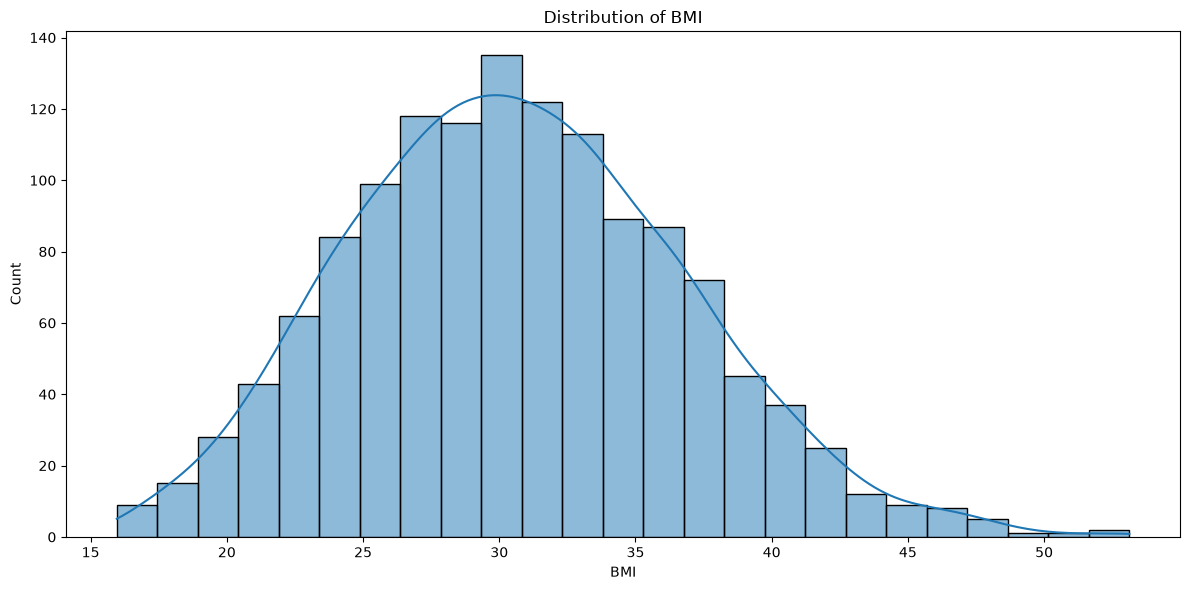

In [81]:
plt.figure(figsize= (12, 6))
sns.histplot(data= df, x='bmi', kde=True)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.tight_layout()
plt.show()

In [82]:
bmi_avg = df['bmi'].mean()
bmi_std = df['bmi'].std()

print(f'Average of BMI: {bmi_avg}\nStd of BMI: {bmi_std}')

Average of BMI: 30.66345175766642
Std of BMI: 6.100468409615801


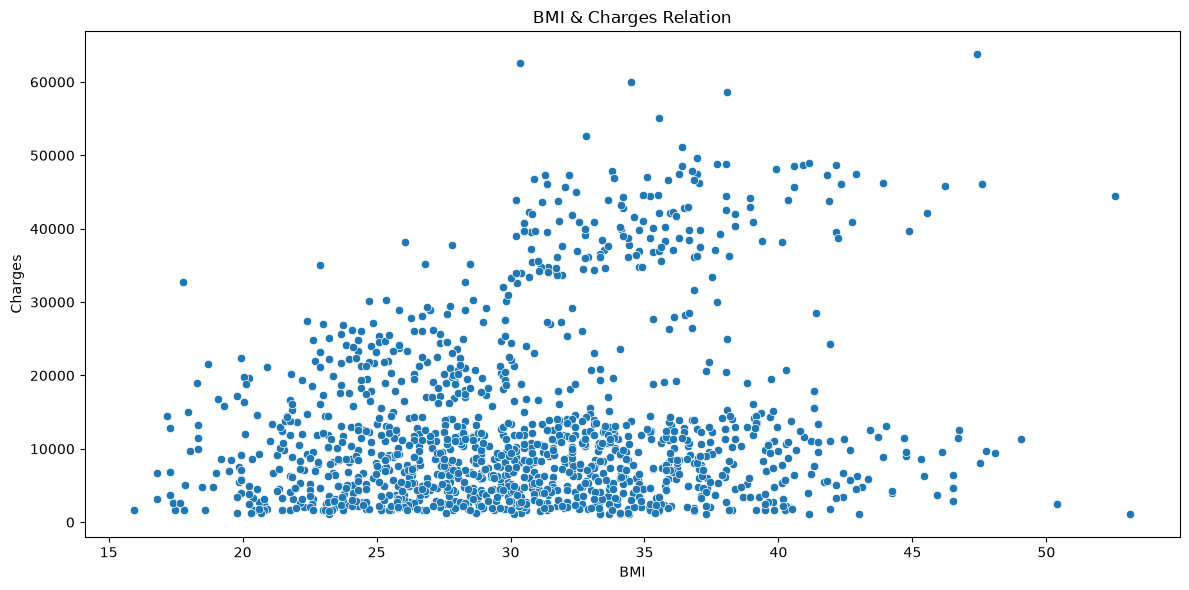

In [83]:
plt.figure(figsize= (12, 6))
sns.scatterplot(data= df, x='bmi', y='charges')
plt.title('BMI & Charges Relation')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.savefig('BMI & Charges relation')
plt.show()


BMI values are concentrated around 25–35, with fewer observations at very low or very high values. The distribution is approximately unimodal, with a slight right tail.

The scatter plot does not show a consistent increase in charges as BMI rises. Most observations have relatively low charges across a wide BMI range, while high-charge cases are more concentrated between BMI 30 and 45. The presence of both low- and high-charge observations at similar BMI levels suggests that BMI alone does not explain the variation in charges.

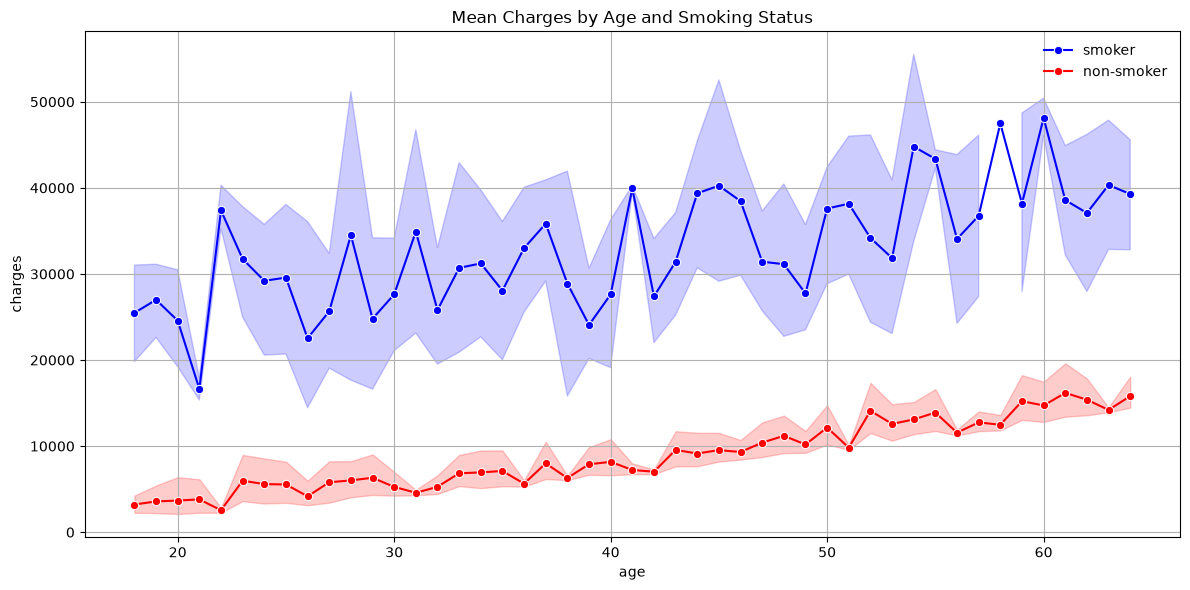

In [ ]:
smokers = df[df['smoker'] == 'yes']
non_smokers = df[df['smoker'] == 'no']

plt.figure(figsize= (12, 6))
sns.lineplot(data= smokers, x='age', y='charges', marker='o', color='blue', label= 'smoker')
sns.lineplot(data= non_smokers, x='age', y='charges', marker='o', color= 'red', label= 'non-smoker')
plt.title('Mean Charges by Age and Smoking Status')
plt.grid(True)  
plt.legend(loc = 'best', frameon= False)
plt.tight_layout()
plt.show()

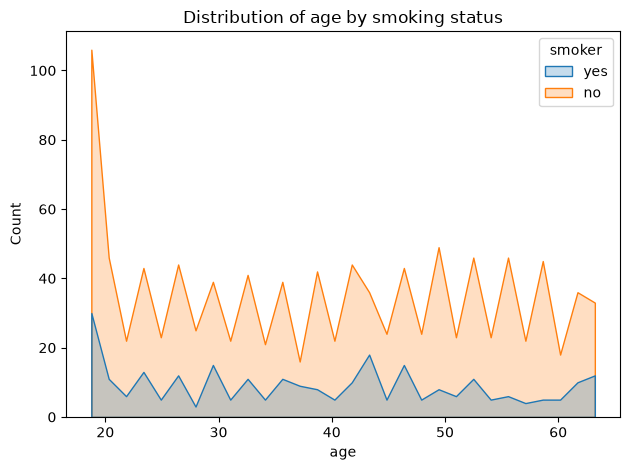

In [85]:
plt.figure()
sns.histplot(df, x='age', hue='smoker',bins=30, element='poly')
plt.title('Distribution of age by smoking status')
plt.tight_layout()
plt.savefig('Distribution of age by smoking status')
plt.show()

Average charges generally increase with age for both smokers and non-smokers. However, smoking status creates a much larger separation in charges than age alone, especially at older ages.

Mean insurance charges generally increase with age for both smokers and non-smokers. However, smokers have substantially higher mean charges across nearly all ages, indicating that the association between age and charges differs considerably by smoking status.

The mean charges for non-smokers follow a relatively steady upward pattern with age, while the smoker group shows larger fluctuations and wider uncertainty intervals. The age-distribution plot helps explain this instability: there are considerably fewer smokers than non-smokers at most ages, so the smoker averages are based on smaller samples and are therefore more sensitive to individual observations.

Both groups contain an unusually high number of observations at the youngest ages, particularly around 18–19. Therefore, the higher count of young smokers does not by itself indicate that smoking is more common among younger people; it mainly reflects the age composition of the dataset.

Overall, age is positively associated with insurance charges, but smoking status separates the observations into two clearly different cost patterns. These findings describe associations within this dataset and do not establish that age or smoking directly caused the differences in charges.

## Conclusion

After removing one duplicate observation, the final dataset contained 1,337 records with no missing values. The distributions of males and females were nearly equal, and the four regions were also relatively balanced, although the Southeast had a slightly larger representation.

Smoking status produced the clearest difference in insurance charges. Smokers represented only 20.49% of the observations but accounted for 49.46% of total charges. Their average charge was 32,050.23, compared with 8,440.66 for non-smokers—approximately 3.8 times higher. This pattern was present among both males and females, while differences between the sexes within the same smoking group were comparatively smaller.

Insurance charges also generally increased with age for both smokers and non-smokers. However, smokers had substantially higher mean charges across nearly all ages. The smoker estimates fluctuated more because fewer smoker observations were available at each age.

BMI values were mainly concentrated between 25 and 35. The relationship between BMI and charges was not consistent across the entire dataset: individuals with similar BMI values could have considerably different charges. Although many high-charge observations appeared between BMI 30 and 45, BMI alone did not explain the variation in insurance charges.

Overall, smoking status showed the strongest observed association with charges, while age also displayed a meaningful positive relationship. BMI provided additional information but appeared insufficient as an independent explanation of cost differences. These findings provide a useful foundation for building a regression model to predict `charges`, while recognizing that the observed relationships do not establish causation.